# LAB 03

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga do conjunto de dados
# trocar o meu caminho onde salvei este arquivo pelo de vocês
#
dados_trafego_aereo = pd.read_csv("./Estatistica_Dados_Passageiros.csv")
#
# Para consultar sobre este conjunto de dados acessar (observar que quebrei o link em duas partes):
# https://www.kaggle.com/datasets/oscarm524
# /san-francisco-air-traffic-passenger-statistics?select=SF_Air_Traffic_Passenger_Statistics.csv

In [3]:
dados_trafego_aereo.head()

,Date,Total Passenger Count
0,200601,2448889
1,200602,2223024
2,200603,2708778
3,200604,2773293
4,200605,2829000


In [4]:
dados_trafego_aereo.shape

(132, 2)

In [5]:
dados_trafego_aereo.dtypes

Date                     int64
Total Passenger Count    int64
dtype: object

In [6]:
dados_trafego_aereo['Date']= pd.to_datetime(dados_trafego_aereo['Date'], format = "%Y%m")

In [7]:
dados_trafego_aereo.dtypes

Date                     datetime64[us]
Total Passenger Count             int64
dtype: object

In [8]:
dados_trafego_aereo

,Date,Total Passenger Count
0,2006-01-01,2448889
1,2006-02-01,2223024
2,2006-03-01,2708778
3,2006-04-01,2773293
4,2006-05-01,2829000
...,...,...
127,2016-08-01,5110638
128,2016-09-01,4543759
129,2016-10-01,4571997
130,2016-11-01,4266481


In [9]:
dados_trafego_aereo.set_index('Date',inplace = True)
dados_trafego_aereo.shape

(132, 1)

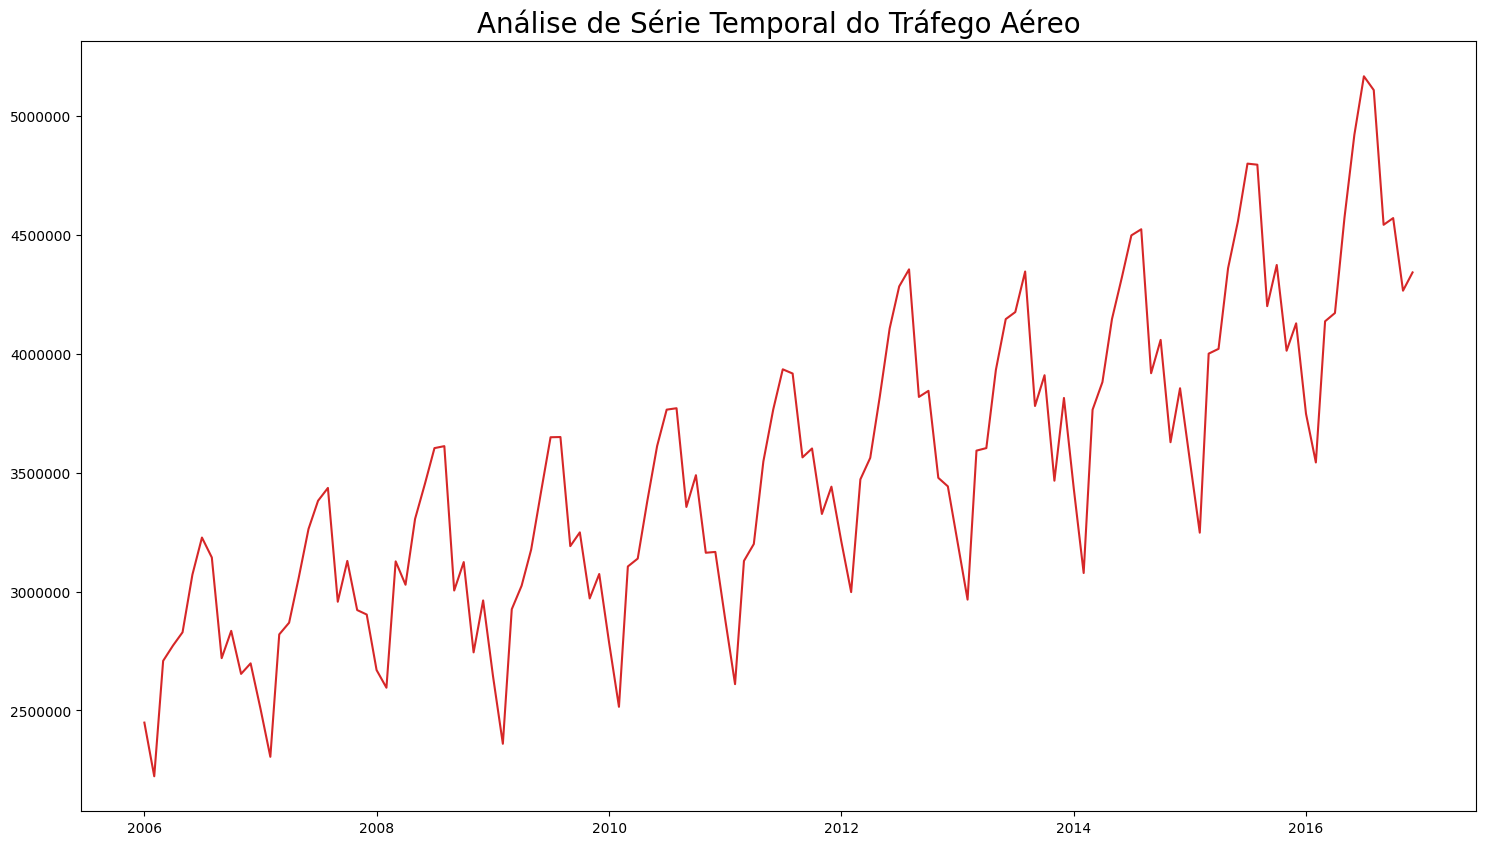

In [10]:
plt.figure(figsize= (18,10))
plt.plot(dados_trafego_aereo.index, dados_trafego_aereo['Total Passenger Count'], color='tab:red')
plt.title("Análise de Série Temporal do Tráfego Aéreo",fontsize = 20)
plt.ticklabel_format(style='plain', axis='y')

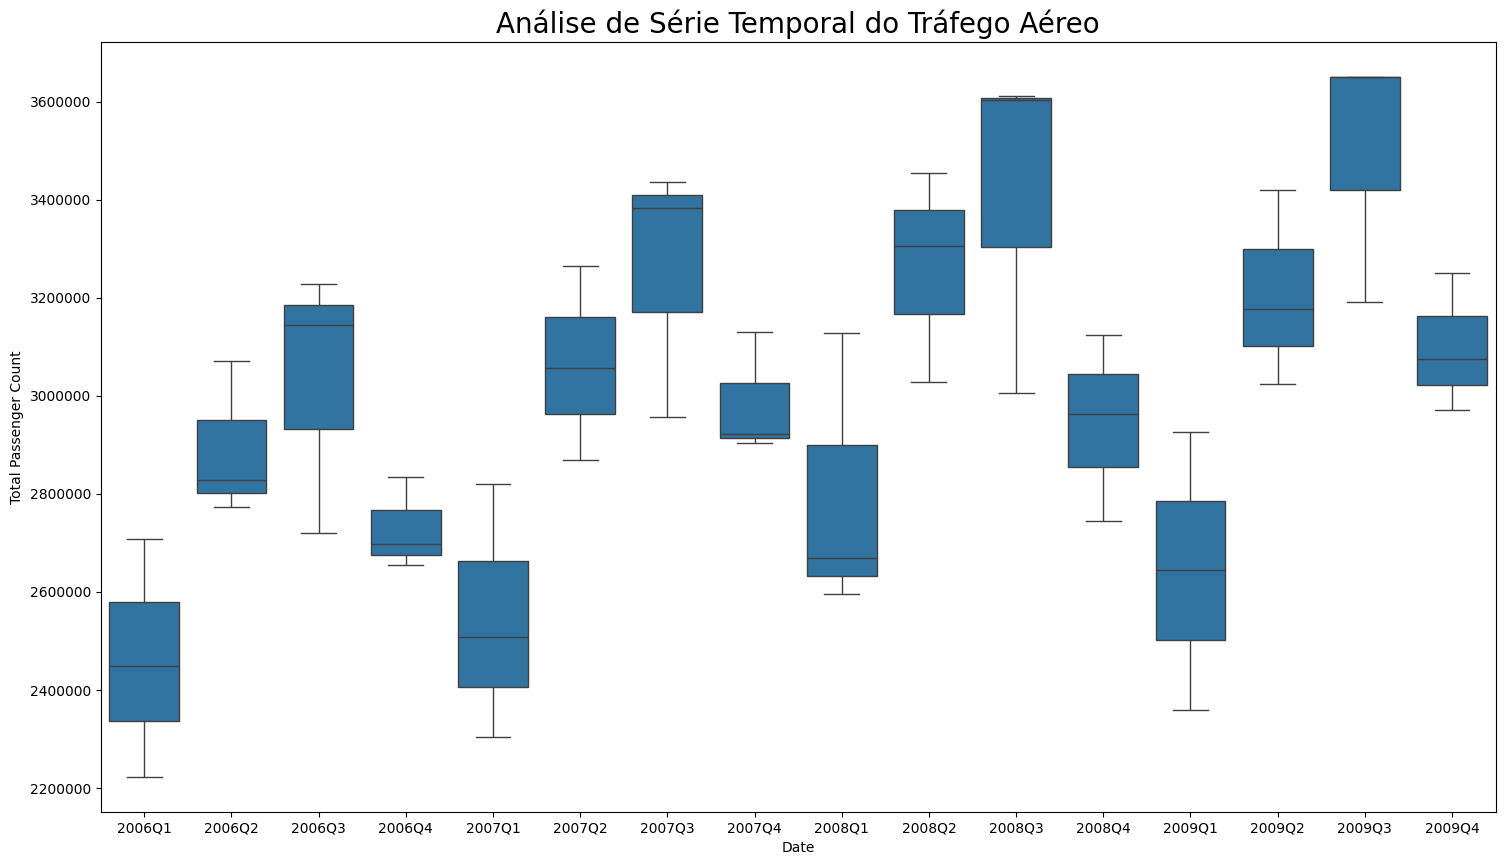

In [11]:
plt.figure(figsize= (18,10))
data_subset = dados_trafego_aereo[dados_trafego_aereo.index < '2010-01-01'] 
ax = sns.boxplot(data = data_subset , x= pd.PeriodIndex(data_subset.index, freq='Q'), y= data_subset['Total Passenger Count'])
ax.set_title("Análise de Série Temporal do Tráfego Aéreo",fontsize = 20)
plt.ticklabel_format(style='plain', axis='y')

# Decomposição de Séries Temporais

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [13]:
dados_trafego_aereo = pd.read_csv("./Estatistica_Dados_Passageiros.csv")
tempo = pd.read_csv("./tempo.csv")

In [14]:
dados_trafego_aereo.head(2)

,Date,Total Passenger Count
0,200601,2448889
1,200602,2223024


In [15]:
tempo.head(2)

,date,meantemp
0,01/01/2013,10.0
1,02/01/2013,7.4


In [16]:
dados_trafego_aereo.shape

(132, 2)

In [17]:
tempo.shape

(1461, 2)

In [18]:
dados_trafego_aereo.dtypes

Date                     int64
Total Passenger Count    int64
dtype: object

In [19]:
tempo.dtypes

date            str
meantemp    float64
dtype: object

In [20]:
dados_trafego_aereo['Date']= pd.to_datetime(dados_trafego_aereo['Date'], format = "%Y%m")

In [21]:
tempo['date']= pd.to_datetime(tempo['date'], format = "%d/%m/%Y")

In [22]:
dados_trafego_aereo.dtypes

Date                     datetime64[us]
Total Passenger Count             int64
dtype: object

In [23]:
tempo.dtypes

date        datetime64[us]
meantemp           float64
dtype: object

In [24]:
dados_trafego_aereo.set_index('Date',inplace = True)

In [25]:
tempo.set_index('date', inplace = True)

In [26]:
dados_trafego_aereo.shape

(132, 1)

In [27]:
tempo.shape

(1461, 1)

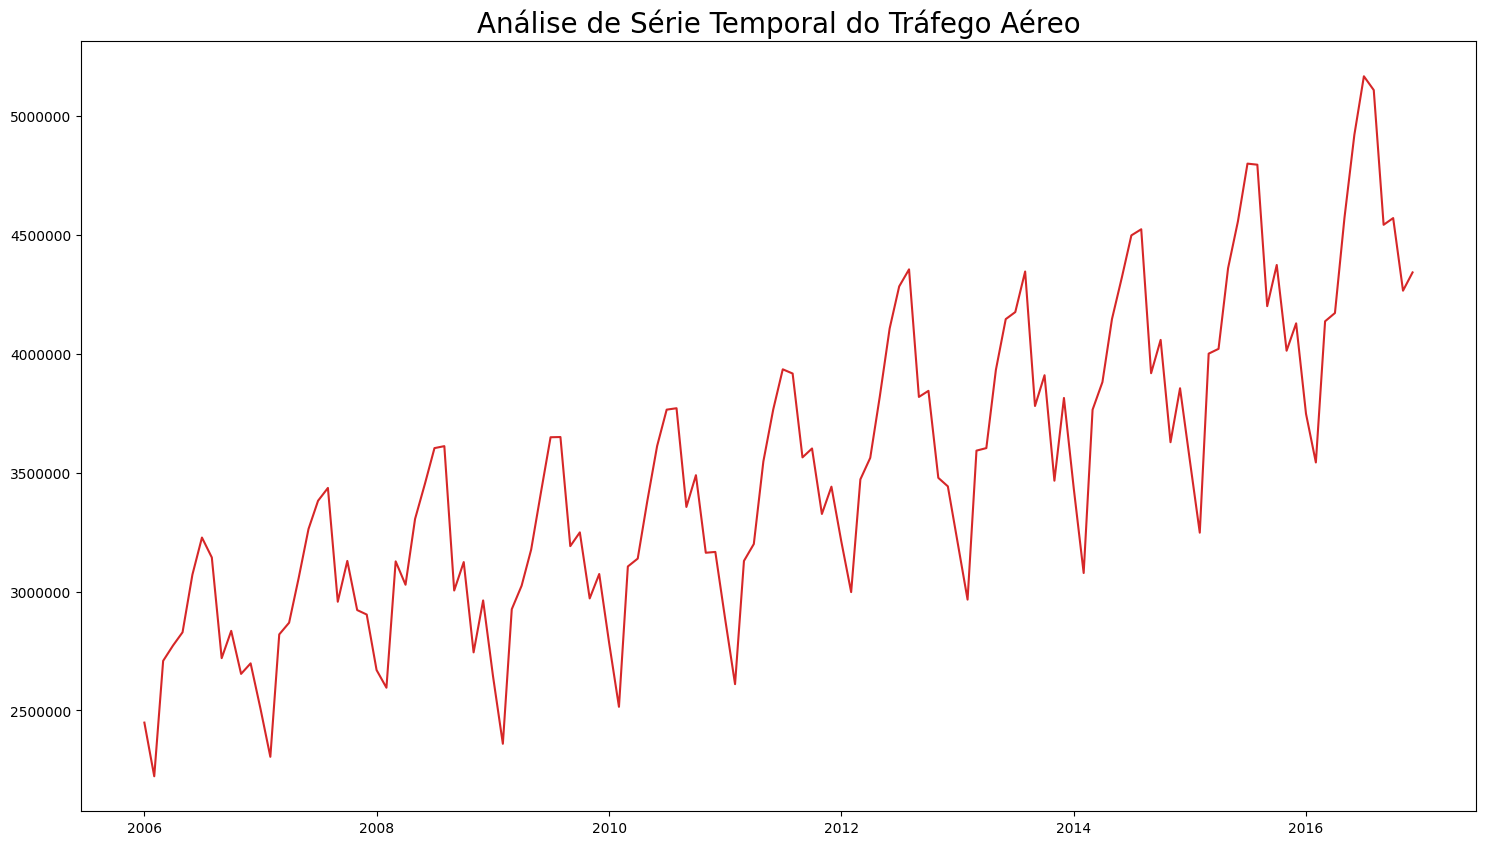

In [28]:
plt.figure(figsize= (18,10))
plt.plot(dados_trafego_aereo.index, dados_trafego_aereo['Total Passenger Count'], color='tab:red')
plt.title("Análise de Série Temporal do Tráfego Aéreo",fontsize = 20)
plt.ticklabel_format(style='plain', axis='y')

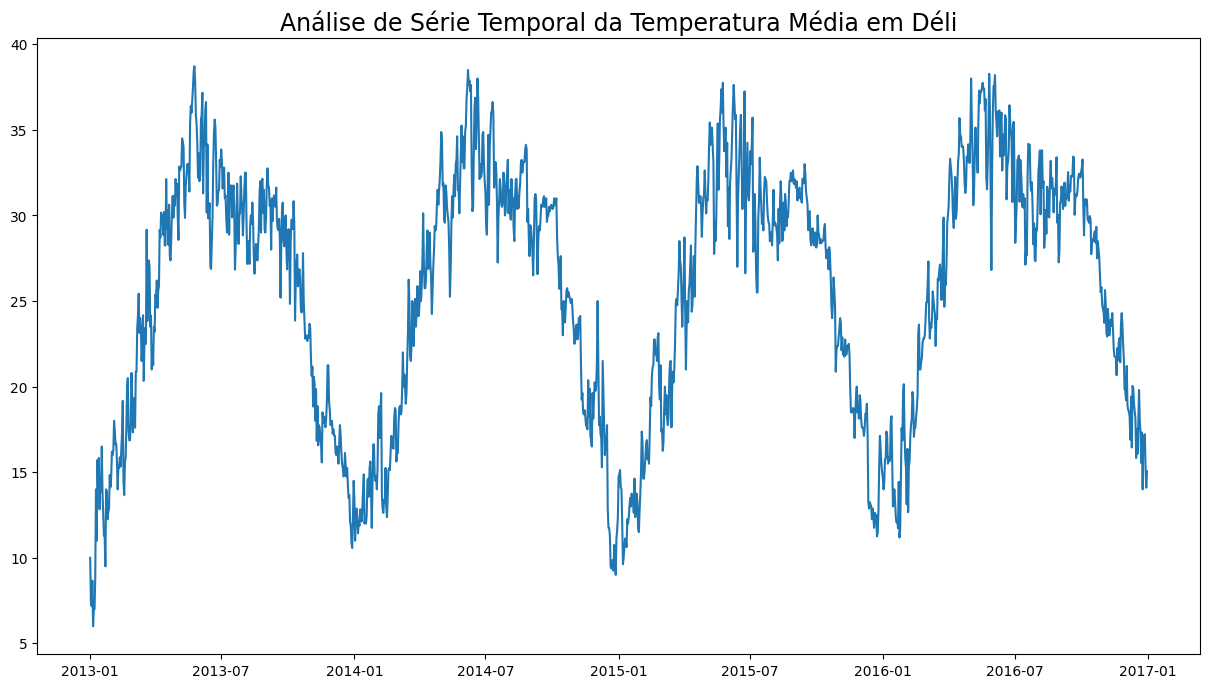

In [29]:
plt.figure(figsize= (15,8))
plt.plot(tempo.index, tempo['meantemp'], color='tab:blue')
plt.title("Análise de Série Temporal da Temperatura Média em Déli",fontsize = 17)
plt.ticklabel_format(style='plain', axis='y')

# Decomposição das série usando o modelo multiplicativo

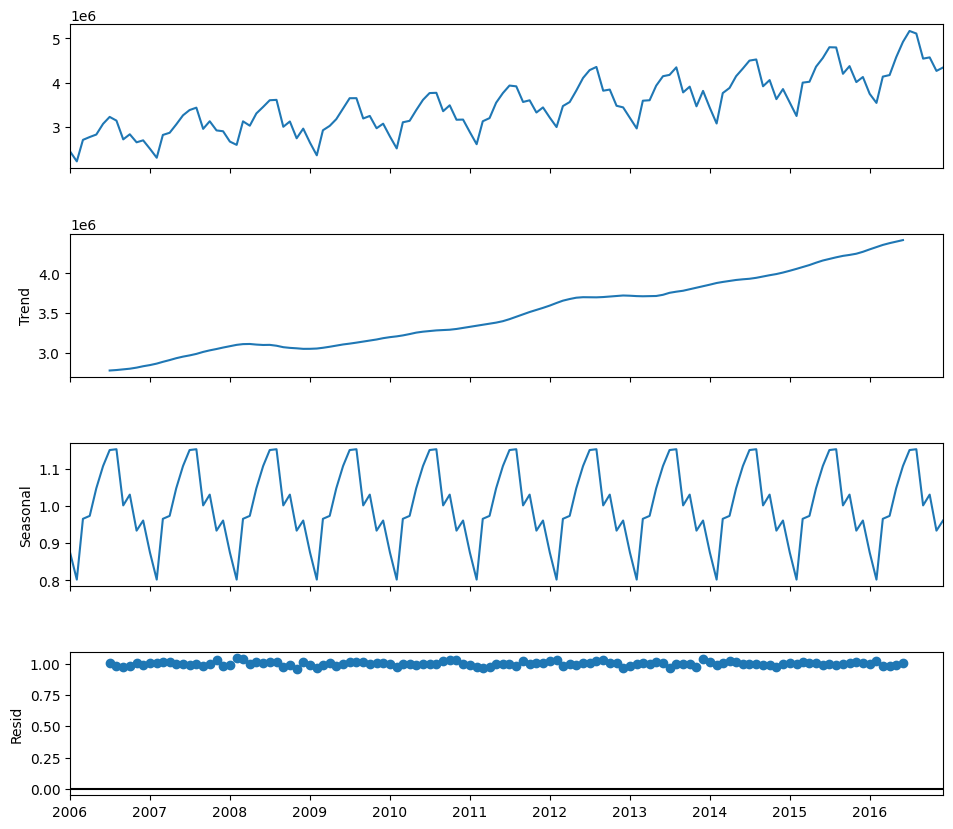

In [30]:
decomposicao_mult = seasonal_decompose(dados_trafego_aereo,model='multiplicative', period = 12)
fig = decomposicao_mult.plot()
fig.set_size_inches((10, 9))
plt.show()

# Decomposição da série usando o modelo aditivo

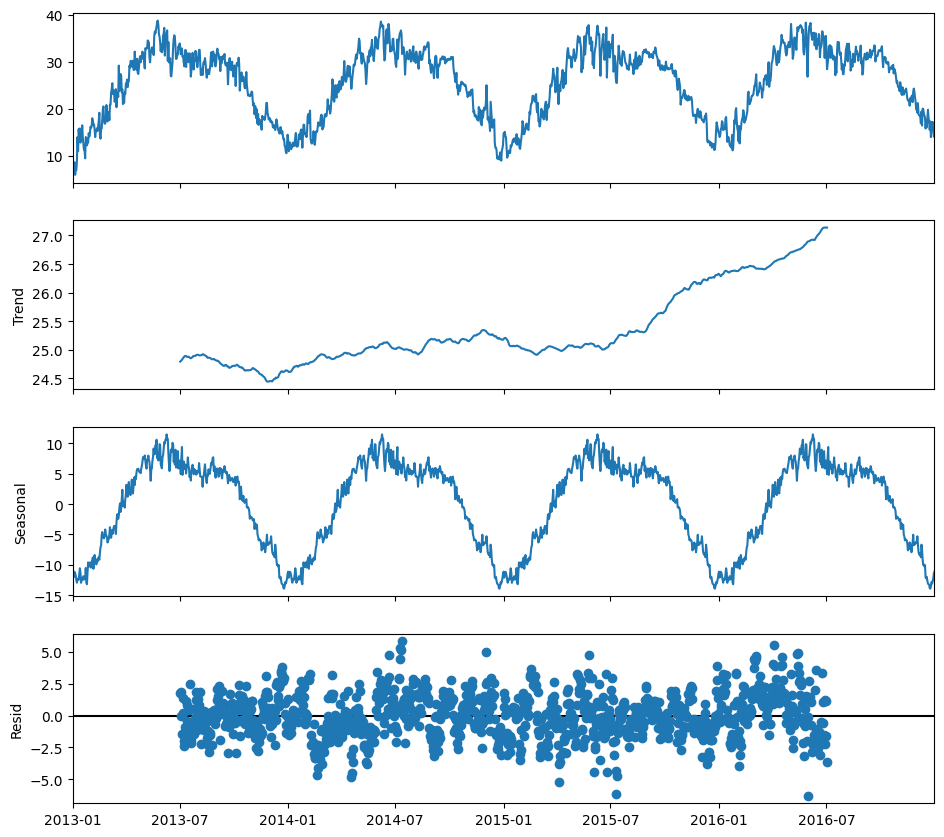

In [31]:
decomposicao_aditiva = seasonal_decompose(tempo, model='additive',period = 365)
fig = decomposicao_aditiva.plot()
fig.set_size_inches((10, 9))
plt.show()

# Suavização - Média Móvel

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# carga dos conjuntos de dados
acoes = pd.read_csv("./financas.csv")
#
# quem desejar verificar os dados no repositório original acessar:
# https://finance.yahoo.com/quote/MTNOY/history/?p=MTNOY 

In [34]:
acoes = acoes [['Date','Close']]

In [35]:
acoes.head()

,Date,Close
0,2010-02-01,14.70
1,2010-02-02,14.79
2,2010-02-03,14.60
3,2010-02-04,14.10
4,2010-02-05,14.28


In [36]:
acoes.shape

(1490, 2)

In [37]:
acoes.dtypes

Date         str
Close    float64
dtype: object

In [38]:
acoes['Date']= pd.to_datetime(acoes['Date'], format = "%Y-%m-%d")

In [39]:
acoes.dtypes

Date     datetime64[us]
Close           float64
dtype: object

In [40]:
acoes.set_index('Date',inplace = True)
acoes.shape

(1490, 1)

Text(0.5, 1.0, 'Análise Série Temporal de Ações')

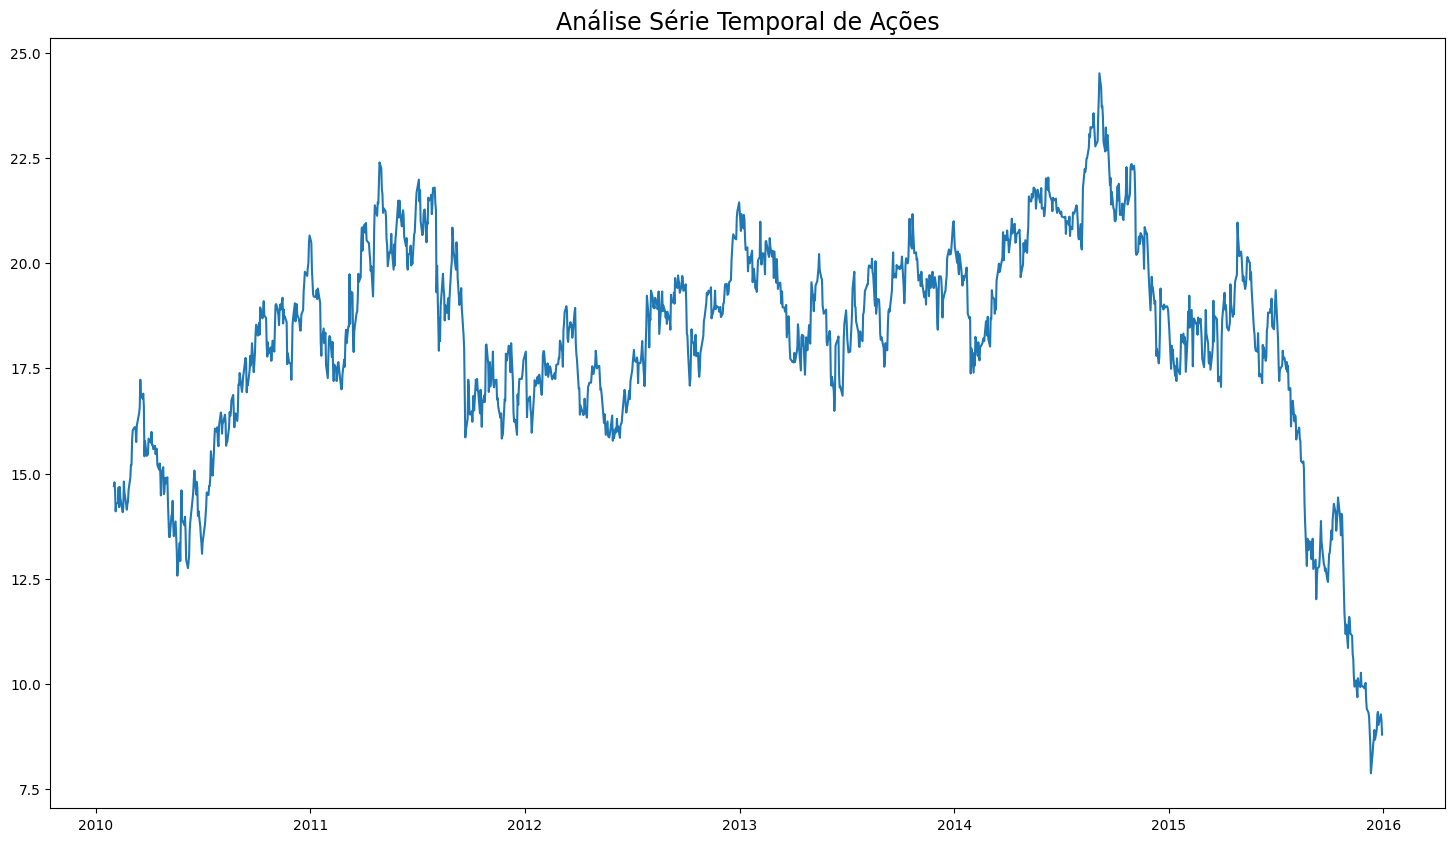

In [41]:
plt.figure(figsize= (18,10))
plt.plot(acoes.index, acoes['Close'],color='tab:blue')
plt.title("Análise Série Temporal de Ações",fontsize = 17)

In [42]:
dados = acoes.rolling(window=4)
dados_media_movel = dados.mean()
dados_media_movel.head()

,Close
Date,
2010-02-01,NaN
2010-02-02,NaN
2010-02-03,NaN
2010-02-04,14.5475
2010-02-05,14.4425


In [43]:
dados_media_movel.head()

,Close
Date,
2010-02-01,NaN
2010-02-02,NaN
2010-02-03,NaN
2010-02-04,14.5475
2010-02-05,14.4425


Text(0.5, 1.0, 'Dados e Média Móvel dos Dados')

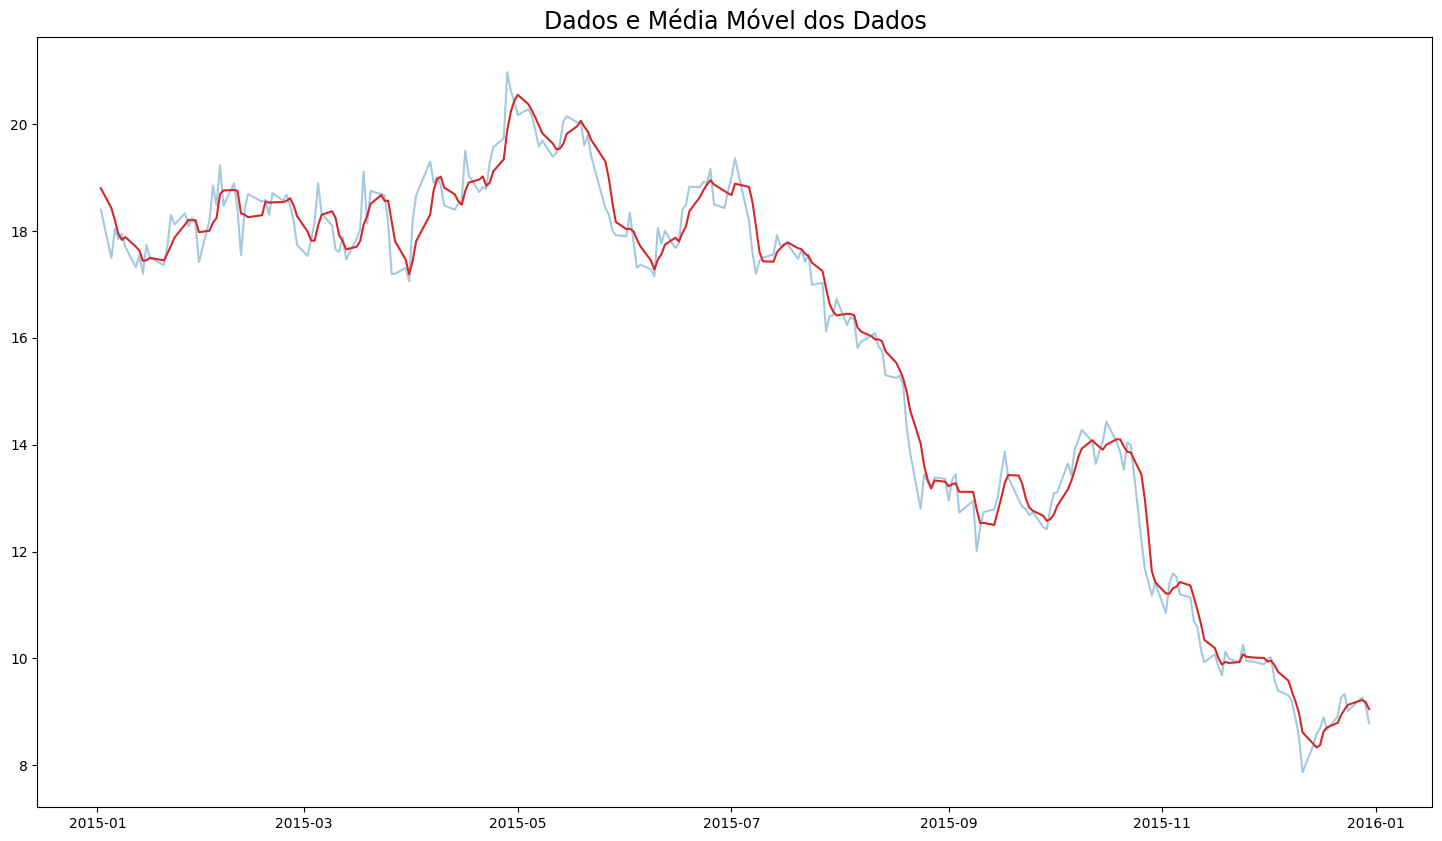

In [44]:
plt.figure(figsize= (18,10))
subconjunto_dados_acoes = acoes[acoes.index>= '2015-01-01']
subconjunto_dados_acoes_media_movel = dados_media_movel[dados_media_movel.index>= '2015-01-01']
plt.plot(subconjunto_dados_acoes.index, subconjunto_dados_acoes['Close'],color='tab:blue',alpha = 0.4)
plt.plot(subconjunto_dados_acoes_media_movel.index, subconjunto_dados_acoes_media_movel['Close'],color='tab:red')
plt.title("Dados e Média Móvel dos Dados",fontsize = 17)

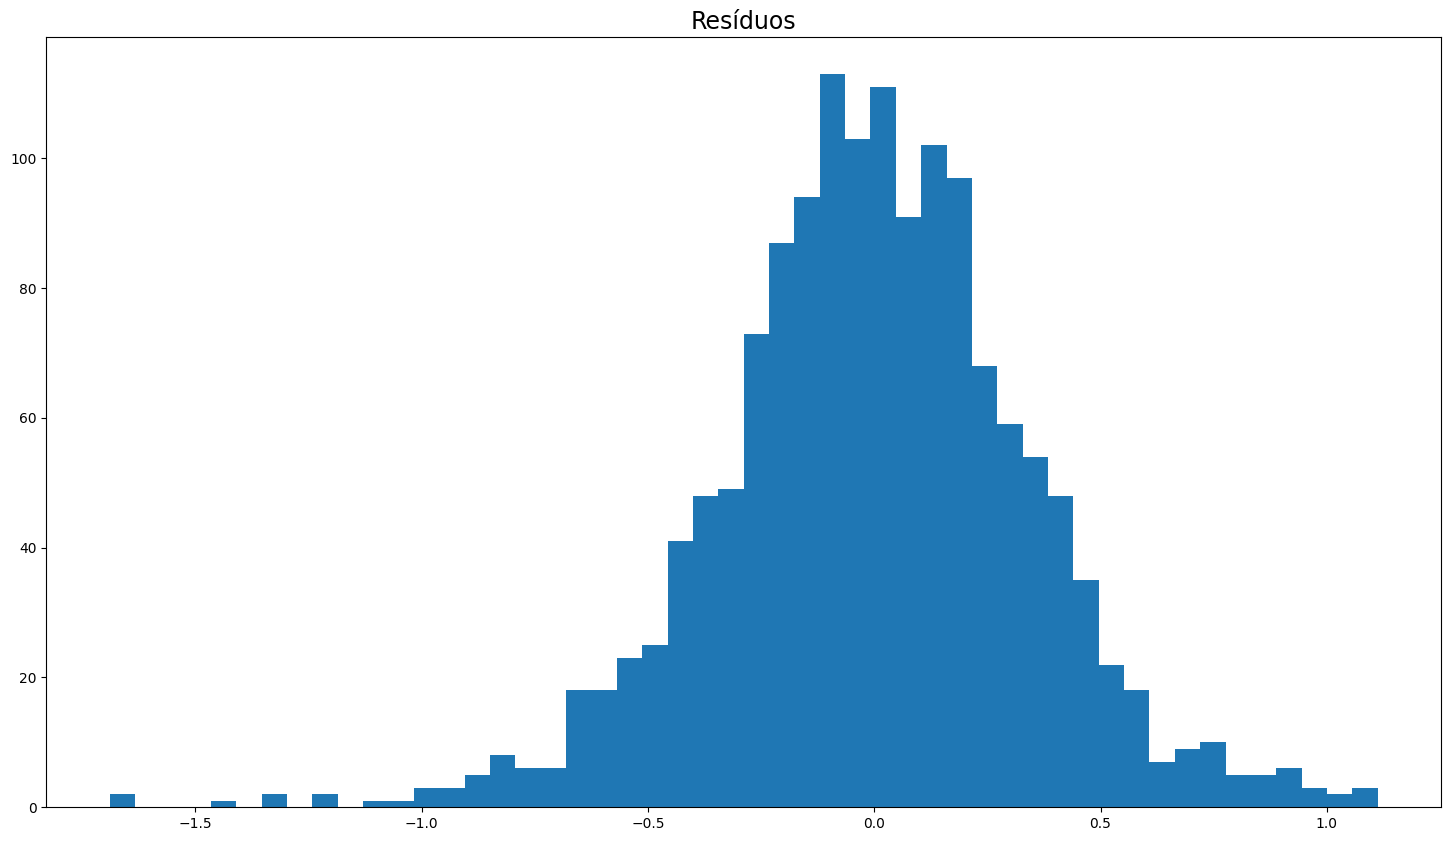

In [45]:
plt.figure(figsize= (18,10))
residuos = acoes - dados_media_movel
plt.hist(residuos, bins=50)
plt.title("Resíduos",fontsize = 17)
plt.show()

In [46]:
percentil_90 = np.nanpercentile(abs(residuos['Close']),90)

In [47]:
residuos[abs(residuos['Close']) >= percentil_90]

,Close
Date,
2010-03-18,0.5750
2010-03-25,-1.0125
2010-05-05,-0.5700
2010-05-06,-0.6625
2010-05-20,-0.6975
...,...
2015-09-17,0.5875
2015-10-26,-1.2250
2015-10-27,-1.3100


# como sugestão para leitura:
# https://machinelearningmastery.com/moving-average-smoothing-for-time-series-forecasting-python/
# reforço a importância de consultar inicialmente o help das ferramentas, bibliotecas e etc que utilizam

# Forte sugestão pesquisar sobre exponential smoothing:
# modelo_exponencial = ExponentialSmoothing(acoes)
# fit = modelo_exponencial.fit(smoothing_level=0.7)

# Realizando verificações de estacionariedade em dados de séries temporais.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

In [49]:
resultado_ADF = adfuller(dados_trafego_aereo)
resultado_ADF

(np.float64(0.7015289287377366),
 np.float64(0.9898683326442054),
 13,
 118,
 {'1%': np.float64(-3.4870216863700767),
  '5%': np.float64(-2.8863625166643136),
  '10%': np.float64(-2.580009026141913)},
 np.float64(3039.0876643475))

In [50]:
print('Teste Estatístico ADF: %f' % resultado_ADF[0])
print('valor-p: %f' % resultado_ADF[1])
print('Valores Críticos:')
print(resultado_ADF[4])
if resultado_ADF[0] < resultado_ADF[4]["5%"]:
    print ("Rejeita Hipótese Nula (H0) - Série Temporal é Estacionária")
else:
    print ("Não Rejeita a Hipótese Nula (H0) - Série Temporal Não-Estacionária")

Teste Estatístico ADF: 0.701529
valor-p: 0.989868
Valores Críticos:
{'1%': np.float64(-3.4870216863700767), '5%': np.float64(-2.8863625166643136), '10%': np.float64(-2.580009026141913)}
Não Rejeita a Hipótese Nula (H0) - Série Temporal Não-Estacionária


# Para consultar:
# https://www.kdnuggets.com/2019/08/stationarity-time-series-data.html

# Para consultar:
# https://www.kdnuggets.com/2019/08/stationarity-time-series-data.html

# Diferenciação de Séries de Dados

In [51]:
dados_trafego_aereo['Difference'] = dados_trafego_aereo['Total Passenger Count'].diff(periods=1)

In [52]:
dados_trafego_aereo = dados_trafego_aereo.dropna()

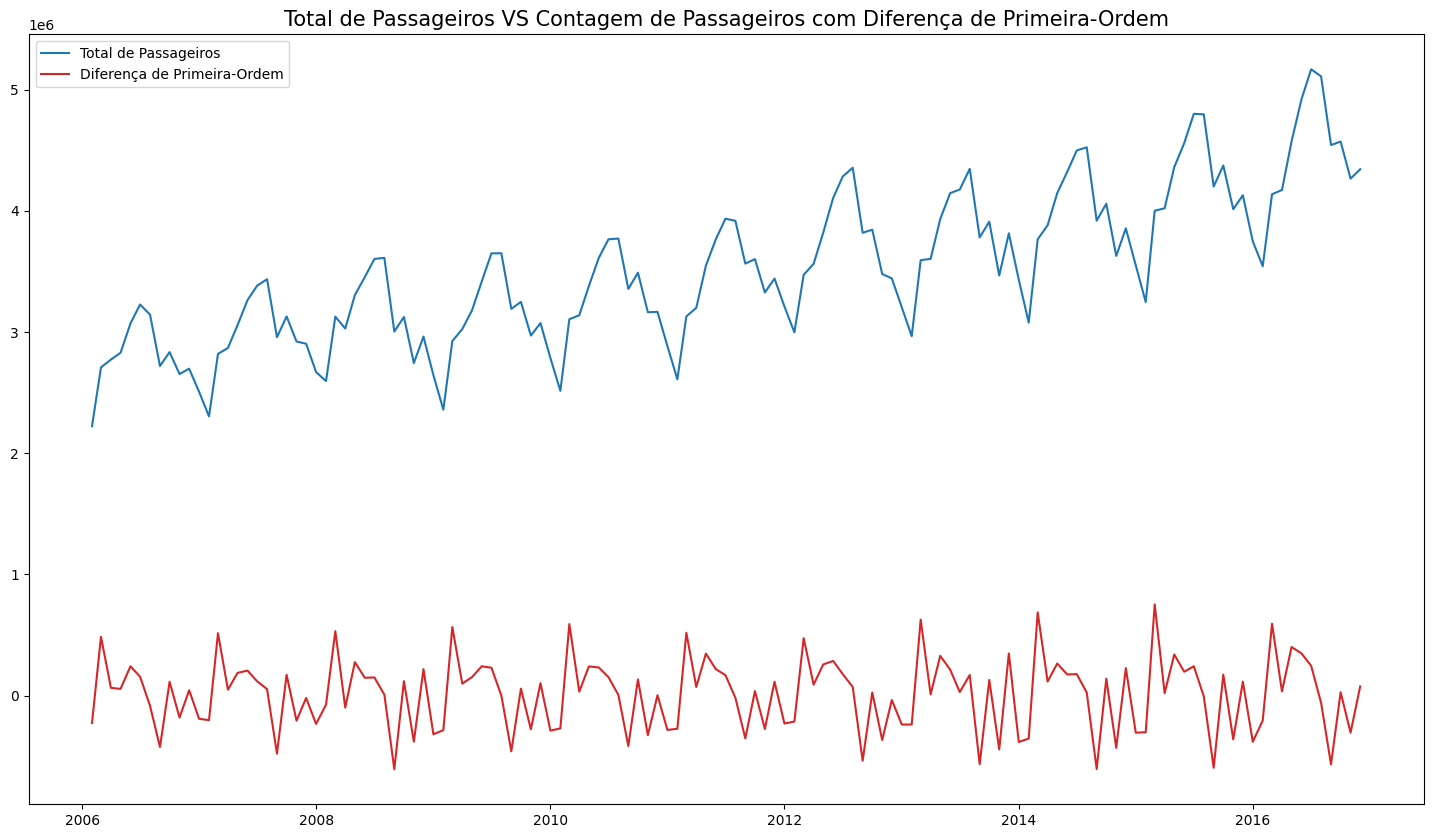

In [53]:
plt.figure(figsize= (18,10))
plt.plot(dados_trafego_aereo['Total Passenger Count'], label='Total de Passageiros')
plt.plot(dados_trafego_aereo['Difference'], label='Diferença de Primeira-Ordem', color='tab:red')
plt.title('Total de Passageiros VS Contagem de Passageiros com Diferença de Primeira-Ordem', size=15)
plt.legend()

In [54]:
resultado_ADF = adfuller(dados_trafego_aereo['Difference'], autolag='AIC')
resultado_ADF

(np.float64(-3.1275649315028744),
 np.float64(0.024579379461460053),
 12,
 118,
 {'1%': np.float64(-3.4870216863700767),
  '5%': np.float64(-2.8863625166643136),
  '10%': np.float64(-2.580009026141913)},
 np.float64(3013.039106024442))

In [55]:
print('Teste Estatístico ADF: %f' % resultado_ADF[0])
print('valor-p: %f' % resultado_ADF[1])
print('Valores Críticos:')
print(resultado_ADF[4])
if resultado_ADF[0] < resultado_ADF[4]["5%"]:
    print ("Rejeita Hipótese Nula (H0) - Série Temporal é Estacionária")
else:
    print ("Não Rejeita a Hipótese Nula (H0) - Série Temporal Não-Estacionária")

Teste Estatístico ADF: -3.127565
valor-p: 0.024579
Valores Críticos:
{'1%': np.float64(-3.4870216863700767), '5%': np.float64(-2.8863625166643136), '10%': np.float64(-2.580009026141913)}
Rejeita Hipótese Nula (H0) - Série Temporal é Estacionária


# Usando gráficos de correlação para visualizar dados de séries temporais

In [56]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
valores_acorr = acf(dados_trafego_aereo[['Total Passenger Count']],nlags = 24)
for i in range(0,25):
    print("Lag " ,i, " " , np.round(valores_acorr[i],2))

Lag  0   1.0
Lag  1   0.86
Lag  2   0.76
Lag  3   0.61
Lag  4   0.46
Lag  5   0.36
Lag  6   0.26
Lag  7   0.33
Lag  8   0.38
Lag  9   0.49
Lag  10   0.59
Lag  11   0.67
Lag  12   0.75
Lag  13   0.63
Lag  14   0.55
Lag  15   0.41
Lag  16   0.28
Lag  17   0.19
Lag  18   0.1
Lag  19   0.16
Lag  20   0.21
Lag  21   0.31
Lag  22   0.41
Lag  23   0.48
Lag  24   0.56


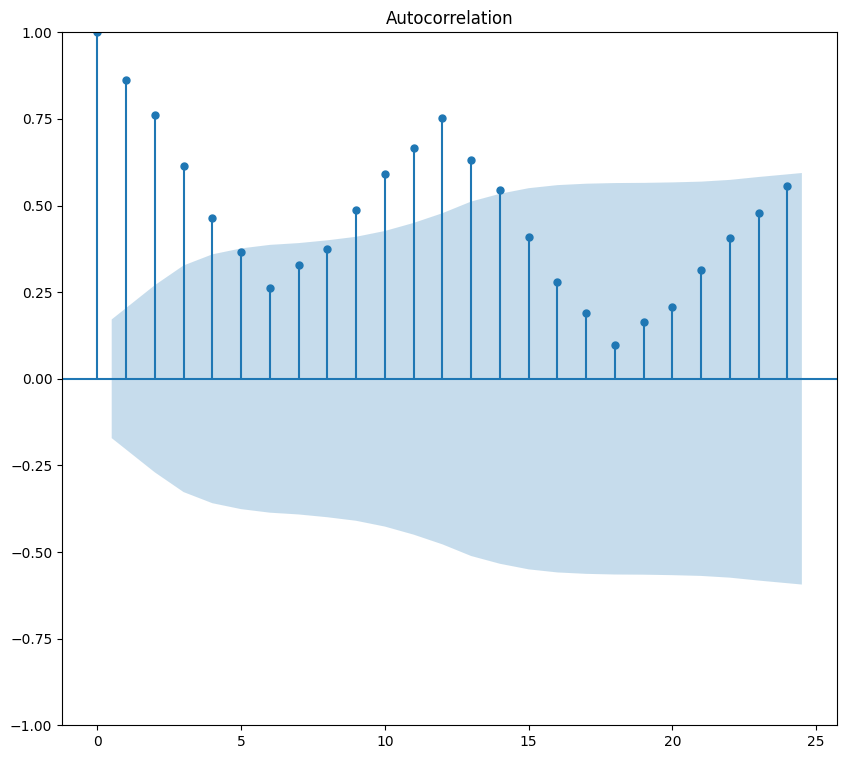

In [57]:
fig= plot_acf(dados_trafego_aereo['Total Passenger Count'],lags = 24)
fig.set_size_inches((10, 9))
plt.show()

In [58]:
valores_acorr_parcial = pacf(dados_trafego_aereo['Total Passenger Count'],nlags=24,method="ols")
for i in range(0,25):
    print("Lag " ,i, " " , np.round(valores_acorr_parcial[i],2))

Lag  0   1.0
Lag  1   0.87
Lag  2   0.05
Lag  3   -0.24
Lag  4   -0.13
Lag  5   0.21
Lag  6   -0.04
Lag  7   0.75
Lag  8   0.19
Lag  9   0.4
Lag  10   0.1
Lag  11   0.43
Lag  12   0.74
Lag  13   -0.63
Lag  14   -0.19
Lag  15   -0.1
Lag  16   0.0
Lag  17   0.21
Lag  18   0.0
Lag  19   -0.04
Lag  20   0.32
Lag  21   0.06
Lag  22   0.24
Lag  23   0.1
Lag  24   0.12


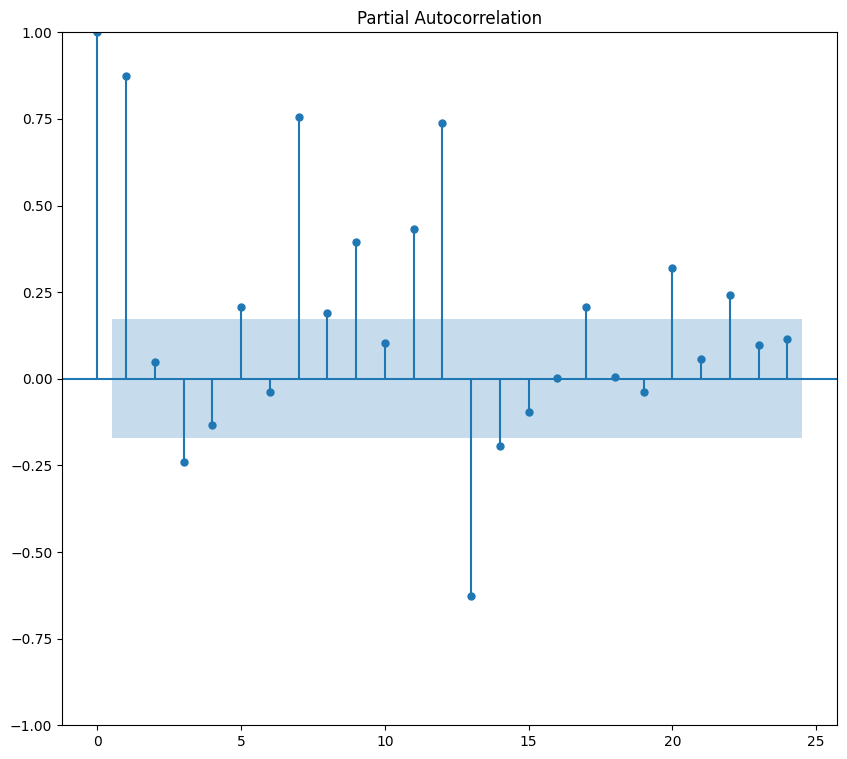

: 

In [ ]:
fig = plot_pacf(dados_trafego_aereo['Total Passenger Count'],method = 'ols', lags=24)
fig.set_size_inches((10, 9))
plt.show()

# para consultar:
# https://towardsdatascience.com/a-step-by-step-guide-to-calculating-autocorrelation-and-partial-autocorrelation-8c4342b784e8/